# Stage 02 — conformance template: submit, then render

This is the **first conformance template**: what an imaging scientist runs locally before
submitting a job to MANIFOLD. It hands the versioned run spec `run_specs/auror_ref.yaml` (authored
in eopticDocs `04-guides/`) to `protodirsig.registry.LocalRegistry`, a local stand-in for
MANIFOLD's submission endpoint, which does not exist yet. Only if the submission is accepted does
it render the job and show the result.

**What acceptance certifies: exactly three things.**

1. **Schema.** The run spec parses, the required `run-spec/1` and `dirsig-engine/1` members are
   present, and every enumerated engine field holds a value the schema permits: the values
   adopted in AV_MANIFOLD_Configuration_v02 A.8, plus the documented `new_atmosphere` extension.
2. **Resolution.** Every engine `ref.name` resolves in `config_repo/` (the engine-asset
   library), the sensor ref resolves beside the run spec, the motion is one this loader can
   generate (static, scene frame, `sceneenu` Euler), and the library platform file agrees with
   the spec's `integration_samples`.
3. **Execution.** DIRSIG accepts the assembled job in a `--dry_run`, which loads every input and
   schedules the captures without rendering, and its JSON log shows the single capture the spec's
   task window implies.

**What it does not certify: radiometric correctness or scientific utility.** A job can pass all
three checks and still render the wrong thing. This one does: the received vehicle target never
shows up in the image (FINDINGS.md, "2026-10-09 — Making the vehicle appear"), and nothing here
detects that. Judging what was rendered is a science review, not a conformance gate.

**A visibility stand-in for the vehicle.** So that there is a target to look at, this notebook
adds an oversized Lambertian disk (albedo 0.8, about 8 pixels across) that flies with the vehicle,
on the vehicle's own motion. It is a sandbox device for seeing the target, not a model of it: the
disk is two orders of magnitude larger than the real ~2 m airframe. `config_repo/` is not
modified. The disk lives in a small library overlay under `outputs/`, and the job is submitted
against that overlay.

**Not the finished template.** Stage 03 split the sensor out as a `sensor-spec/1` ref
(`run_specs/sensors/`, one entry so far). Stage 04 moved the engine assets into a library,
`config_repo/`. Stage 05 generates the motion and tasks files from the run spec, so nothing is
read from a received tree; `AUROR_ref/` survives only as a test fixture. Sweep tooling (Phase 6)
was dropped. See eopticDocs
`projects/MANIFOLD/review/PLAN_2026-10-08_conformance-template-roadmap.md`.
This is staged implementation, not a tutorial. For dirfm usage itself, see the `tutorial_*`
notebooks. `stage_01_auror_from_runspec` is the same job with the assembly done in notebook cells.

| Piece | From |
|---|---|
| Submission verdict and reasons | `protodirsig.registry.LocalRegistry` |
| The three checks, and the render with JSON run/info logs | `protodirsig.simulation.Simulation` |
| Run spec → resolved library/tree files; spec-vs-file check | `protodirsig.run_spec` (Stage 01, 04) |
| Scene reference, input copies, fingerprint guard | `protodirsig.scene_ref` |
| Band coverage of the scene's real materials | `protodirsig.scene_coverage` |

| Stage | What it does |
|---|---|
| 0 | Add the visibility disk; submit the run spec; read the verdict; check the scene's materials cover the sensor band |
| 1 | If accepted, render, then look at the image, the disk and the geolocation truth |

---
# Stage 0 — Submit

## Environment

This uses the same convention as the other notebooks. `DIRSIG_HOME` comes from the environment,
with this machine's install as the fallback, and its `bin/` goes on `PATH`. `protodirsig` is
imported from `src/`. Everything the job writes goes under `outputs/stage_02_auror/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
WORK = PROJECT / "outputs" / "stage_02_auror"

try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

RUN_SPEC = PROJECT / "run_specs" / "auror_ref.yaml"     # vendored; edit in eopticDocs 04-guides/
print("DIRSIG_HOME :", DIRSIG_HOME)
print("run spec    :", RUN_SPEC.relative_to(PROJECT))
CONFIG_REPO = PROJECT / "config_repo"                    # read-only engine-asset library
print("config_repo :", CONFIG_REPO, "exists" if CONFIG_REPO.is_dir() else "MISSING")
assert RUN_SPEC.is_file() and CONFIG_REPO.is_dir()

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
run spec    : run_specs/auror_ref.yaml
config_repo : /home/kevin-kearney/dev/protoDIRSIG/config_repo exists


## A visibility stand-in for the vehicle

The received vehicle is a ~2 m mesh 500 km below the sensor, so it covers about 0.3 % of one
pixel, and its material (`Gidder_mat`) has zero reflectance. It never shows up in the frame
(FINDINGS.md, 2026-10-09). To have a visible target, this cell adds a flat disk that a sensor
this far away can't miss:

* **Size.** It is 8 pixels across at the vehicle's range. The pixel footprint there is computed
  from the library's own files, not typed in: pitch ÷ focal length from the platform file, times
  the sensor-to-vehicle distance (the run spec's sensor height minus the vehicle's start height
  in `lists/hypersonic.glist`).
* **Material.** Lambertian, albedo 0.8: a `WardBRDF` with diffuse weight 0.8 and no specular
  term, the manual's recipe for a diffuse reflector. DIRSIG requires a radiometry solver with
  any surface properties; it gets the same `Generic` solver settings as the vehicle's material.
* **Placement.** The disk gets a copy of the vehicle's own `<dynamicinstance>` (the `straight`
  motion), so it sits wherever the vehicle is at the task time. Its normal is +Z (the default),
  facing the sensor overhead.

None of this touches `config_repo/`. `LIBRARY` mirrors it under `outputs/`, with every file a
symlink back to the original. Only two things there are new: a copy of `tahoe.scene` with one
extra `<geometrylistinclude>`, and the disk's `.glist` and `.mat`. The job is submitted against
`LIBRARY`, and `config_repo/` is still fingerprinted around the render.

In [2]:
import copy
import lxml.etree as et
import yaml

DISK_PIXELS, DISK_ALBEDO = 8, 0.8
LIBRARY = PROJECT / "outputs" / "stage_02_library"       # config_repo/ mirrored, plus the disk
SCENE_DIR = Path("scenes/tahoe")

# Pixel footprint at the vehicle, from the library's own files.
plat = et.parse(str(CONFIG_REPO / "platforms/AurorNIRDetector/AurorNIRDetector.platform")).getroot()
focal_m = float(plat.findtext(".//instrument/properties/focallength")) * 1e-3          # mm
pitch_m = float(plat.findtext(".//detectorarray/xelementsize")) * 1e-6                 # microns
vehicle = et.parse(str(CONFIG_REPO / SCENE_DIR / "geometry/lists/hypersonic.glist")).getroot()
vehicle_z = float(vehicle.findtext(".//locationengine/start/z"))
sensor_z = yaml.safe_load(RUN_SPEC.read_text())["engine"]["motion"]["position"]["xyz"][2]
GSD = pitch_m / focal_m * (sensor_z - vehicle_z)
DISK_RADIUS = DISK_PIXELS * GSD / 2

# Mirror config_repo/: real directories, every file a symlink to the original.
if LIBRARY.exists():
    shutil.rmtree(LIBRARY)                 # our own directory; rmtree unlinks symlinks, never follows them
for d, _, files in os.walk(CONFIG_REPO):
    rel_dir = Path(d).relative_to(CONFIG_REPO)
    (LIBRARY / rel_dir).mkdir(parents=True, exist_ok=True)
    for f in files:
        (LIBRARY / rel_dir / f).symlink_to(Path(d) / f)

# The disk: a GLIST primitive with a local material, on a copy of the vehicle's motion.
lists = LIBRARY / SCENE_DIR / "geometry/lists"
(lists / "visibility_disk.mat").write_text(f"""MATERIAL_ENTRY {{
    ID   = visibility_disk
    NAME = Visibility disk (Lambertian, albedo {DISK_ALBEDO})
    RAD_SOLVER_NAME = Generic
    RAD_SOLVER {{
        INITIAL_SAMPLE_COUNT = 100
        SAMPLE_DECAY_RATE    = 2
        MAX_BOUNCES          = 3
        MU_SAMPLES           = 10
        PHI_SAMPLES          = 20
        MIN_QUAD_SAMPLES     = 1
    }}
    TEMP_SOLVER_NAME = DataDriven
    TEMP_SOLVER {{
        TEMPERATURE = 270
    }}
    SURFACE_PROPERTIES {{
        REFLECTANCE_PROP_NAME = WardBRDF
        REFLECTANCE_PROP {{
            DS_WEIGHTS = {DISK_ALBEDO} 0.00
            XY_SIGMAS  = 0.00 0.00
        }}
    }}
}}
""")
glist = et.Element("geometrylist")
obj = et.SubElement(glist, "object", search_paths="local")
et.SubElement(obj, "localmaterials").text = "visibility_disk.mat"
disk = et.SubElement(et.SubElement(obj, "basegeometry"), "disk")
et.SubElement(disk, "matid").text = "visibility_disk"
et.SubElement(disk, "radius").text = f"{DISK_RADIUS:.3f}"
motion = copy.deepcopy(vehicle.find(".//dynamicinstance"))
motion.set("name", "::IMPORTANT::visibility_disk")
obj.append(motion)
et.ElementTree(glist).write(str(lists / "visibility_disk.glist"), pretty_print=True)

# The scene: a copy of tahoe.scene with one more include, in place of the symlink.
scene_file = LIBRARY / SCENE_DIR / "tahoe.scene"
scene = et.parse(str(CONFIG_REPO / SCENE_DIR / "tahoe.scene"))
inc = et.SubElement(scene.getroot().find("geometrylist"), "geometrylistinclude",
                    name="Visibility disk", enabled="true")
inc.text = "lists/visibility_disk.glist"
scene_file.unlink()
scene.write(str(scene_file))

print(f"pixel footprint at the vehicle: {pitch_m * 1e6:.0f} um / {focal_m * 1e3:.0f} mm x "
      f"{sensor_z - vehicle_z:.0f} m = {GSD:.2f} m")
print(f"disk: {DISK_PIXELS} px -> radius {DISK_RADIUS:.1f} m (diameter {2 * DISK_RADIUS:.1f} m), "
      f"Lambertian albedo {DISK_ALBEDO}")
print(f"motion: copy of the vehicle's '{vehicle.find('.//locationengine').get('type')}' engine, start "
      f"({vehicle.findtext('.//start/x')}, {vehicle.findtext('.//start/y')}, {vehicle_z:.0f})")
print(f"library: {LIBRARY.relative_to(PROJECT)} "
      f"(new: {[p.relative_to(LIBRARY).as_posix() for p in LIBRARY.rglob('*') if p.is_file() and not p.is_symlink()]})")


pixel footprint at the vehicle: 10 um / 306 mm x 500000 m = 16.34 m
disk: 8 px -> radius 65.4 m (diameter 130.7 m), Lambertian albedo 0.8
motion: copy of the vehicle's 'straight' engine, start (-400.0, 400.0, 50000)
library: outputs/stage_02_library (new: ['scenes/tahoe/tahoe.scene', 'scenes/tahoe/geometry/lists/visibility_disk.mat', 'scenes/tahoe/geometry/lists/visibility_disk.glist'])


## Submitting the run spec

`LocalRegistry().submit` builds a `Simulation` from the run spec, runs its three checks, and
returns a verdict with one plain-language reason per failed check. All three checks always run;
a failure in one doesn't hide the others. Nothing is rendered here. The execution check assembles
the same job Stage 01 assembled (scene reference, byte-identical library copies, generated
motion and tasks, `BasicPlatform`,
`NewAtmosphere`, `SpiceEphemeris`, `ThermWeather`, seed) under `validate/`, and runs it through
dirfm's `DIRSIG.run` with `--dry_run --log_info_filename=...`. That takes about a second.

The job is submitted against `LIBRARY`, the mirror with the disk added. Every path in it except
the scene copy and the disk files resolves to `config_repo/`. `config_repo/` itself is
fingerprinted here and again after the render, and the render cell asserts that nothing in it
changed.

In [3]:
from protodirsig.registry import LocalRegistry
from protodirsig.scene_ref import fingerprint

if WORK.exists():
    shutil.rmtree(WORK)                    # our own directory; rmtree unlinks symlinks, never follows them
before = fingerprint(CONFIG_REPO)
submission = LocalRegistry().submit(RUN_SPEC, LIBRARY, WORK)   # config_repo/ plus the disk
sim = submission.simulation
run = sim.auror_run

print(f"verdict : {submission.verdict.upper()}")
for check, ok in submission.checks.items():
    print(f"  {check:10s} {'pass' if ok else 'FAIL'}")
for reason in submission.reasons:
    print(f"  - {reason}")
if run is not None:
    rel = lambda p: f"{LIBRARY.name}/{p.relative_to(LIBRARY).as_posix()}"
    print(f"\nmeta.name   : {run.name}; origin {run.origin}")
    print(f"atmosphere  : {sim.spec['engine']['atmosphere']['plugin']} (non-adopted dirsig-engine/1 extension), "
          f"database {rel(run.atmosphere_db)}")
    print(f"scene       : {sim.spec['engine']['scenes'][0]['ref']['name']} -> {rel(run.scene)}")
    print(f"platform    : {rel(run.platform)}")
    print(f"motion      : generated: static, scene {run.motion_position}, euler {run.motion_orientation['order']} "
          f"{run.motion_orientation['angles']} {run.motion_orientation['units']} (sceneenu)")
    print(f"tasks       : generated: epoch {run.epoch.isoformat()}, windows {run.tasks_windows}")
    print(f"weather     : {rel(run.weather)}; ephemeris {run.ephemeris}; seed {run.seed}")
if submission.accepted:
    import json
    caps = json.loads((sim.work_dir / "validate" / "log_info.json").read_text())["capture_list"]
    cap = caps[0]
    print(f"\ndry run     : {len(caps)} capture, task {cap['task_index']}, window {cap['relative_time_window']} s, "
          f"'{cap['description']}' -> {Path(cap['plugin_data']['filename']).name}")

Material [Dummy] ID has already been set to [N/A], can't override.


verdict : ACCEPTED
  schema     pass
  resolution pass
  execution  pass

meta.name   : auror-ref-static-pose; origin {'kind': 'synthetic', 'engine': 'dirsig'}
atmosphere  : new_atmosphere (non-adopted dirsig-engine/1 extension), database stage_02_library/atmosphere/AurorNewAtmosphere
scene       : scenes/tahoe/tahoe.scene -> stage_02_library/scenes/tahoe/tahoe.scene
platform    : stage_02_library/platforms/AurorNIRDetector/AurorNIRDetector.platform
motion      : generated: static, scene [-400.0, 400.0, 550000.0], euler xyz [0.0, 0.0, 3.141592654] radians (sceneenu)
tasks       : generated: epoch 2009-07-27T19:29:32+00:00, windows [(0.0, 0.0)]
weather     : stage_02_library/weather/saw.wth; ephemeris spice; seed 42

dry run     : 1 capture, task 0, window [0.0, 0.005] s, 'Auror NIR Detector -> CIS120' -> AurorNIROutput.img


## The scene and band coverage

The submission's checks say nothing about whether the scene's materials have spectral data
across the sensor's band, so this stays a separate check. It reads the resolved `tahoe.scene`
and every bundle material it reaches, including the vehicle's `Gidder_mat` and the disk's
`visibility_disk`. The scene origin is
also read here, for the geolocation check after the render.

In [4]:
import lxml.etree as et
from protodirsig.scene_coverage import scene_coverage

assert submission.accepted, "submission rejected: see the reasons above; not continuing"
loc = et.parse(str(run.scene)).getroot().find("sceneorigin/location")
LAT0, LON0, ALT0 = (float(loc.findtext(k)) for k in ("latitude", "longitude", "altitude"))
bp = et.parse(str(run.platform)).getroot().find(".//capturemethod/spectralresponse/bandpass")
BAND = (float(bp.findtext("minimum")), float(bp.findtext("maximum")))

cov = scene_coverage(run.scene)
for m in cov.materials:
    lo, hi = m.span
    print(f"  {m.id:>10s}  {m.name:22s} {lo:.2f}-{hi:.2f} um   ({m.source.name})")
print(f"scene origin {LAT0}, {LON0}, {ALT0} m")
print(f"sensor band {BAND[0]}-{BAND[1]} um covered by every material: {cov.covers(*BAND)}")
assert cov.covers(*BAND)

           1  Terrain (proxy)        0.20-20.00 um   (tahoe.mat)
          11  Water                  0.40-15.60 um   (tahoe.mat)
          12  Class #2               0.40-15.60 um   (tahoe.mat)
          13  Class #3               0.40-15.60 um   (tahoe.mat)
          14  Class #4 (asphalt)     0.40-15.60 um   (tahoe.mat)
          15  Class #5 (grass)       0.40-15.60 um   (tahoe.mat)
          16  Class #6 (coniferous)  0.40-15.60 um   (tahoe.mat)
          17  Class #7 (Pine Tree)   0.40-15.60 um   (tahoe.mat)
          18  Class #8               0.40-15.60 um   (tahoe.mat)
          19  Class #9 (concrete)    0.40-15.60 um   (tahoe.mat)
  Gidder_mat  Gidder_mat             0.40-3.00 um   (hypersonic.mat)
  visibility_disk  Visibility disk (Lambertian, albedo 0.8) -inf-inf um   (visibility_disk.mat)
scene origin 39.0, -120.0, 0.0 m
sensor band 0.41-2.0 um covered by every material: True


---
# Stage 1 — Render and inspect (accepted submissions only)

`sim.run()` assembles the same job again under `input/`. It compiles the scene with this
install's `scene2hdf`, then renders with `dirsig5`. It also passes `--run_info_filename` and
`--log_info_filename`, so the render leaves two JSON logs beside its images:

* `run_info.json`: the compiled scene (HDF path, bounding box, MD5) and each plugin's resolved
  inputs.
* `log_info.json`: each capture's schedule, sensor pose, ground corner points and output
  filenames.

These are DIRSIG's own record of what it ran, kept for provenance. The image paths below come
from `log_info`, not from names written into this notebook. A render takes a few minutes on this
machine.

In [5]:
import time

assert submission.accepted, "submission rejected: not rendering"
t0 = time.perf_counter()
result = sim.run()
elapsed = time.perf_counter() - t0
after = fingerprint(CONFIG_REPO)
OUT_DIR = result.output_dir

scene_log = result.run_log["scene_list"][0]
print(f"run() {elapsed:.0f} s")
print(f"config_repo fingerprint: {len(before)} paths, unchanged = {before == after}")
print(f"outputs               : {sorted(p.name for p in OUT_DIR.iterdir())}")
print(f"image / truth         : {result.image.name} / {[p.name for p in result.truth]}")
print(f"run_info scene        : {scene_log['filename']}, md5 {scene_log['md5']}")
print(f"run_info plugins      : {[p['name'] for p in result.run_log['plugin_list']]}")
print(f"[warn] lines          : {len(result.warnings)}, e.g. {result.warnings[0] if result.warnings else None}")
assert before == after, "config_repo changed"
assert result.image.is_file() and all(p.is_file() for p in result.truth)

Material [Dummy] ID has already been set to [N/A], can't override.


run() 236 s
config_repo fingerprint: 36 paths, unchanged = True
outputs               : ['AurorNIROutput.img', 'AurorNIROutput.img.hdr', 'log_info.json', 'run_info.json', 'truth1.img', 'truth1.img.hdr']
image / truth         : AurorNIROutput.img / ['truth1.img']
run_info scene        : auror_ref/tahoe.scene.hdf, md5 a16907114fbf6c615111ab9cb2a86d18
run_info plugins      : ['NewAtmosphere', 'BasicPlatform']
[warn] lines          : 22, e.g. [warn] ../../../config_repo/scenes/tahoe/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm


The `[warn]` lines are `dirsig5`'s, as expected for this scene. Materials 11–19 are unused because the material map is disabled. The terrain is 13 × 28 km, past the 10 km precision advisory. Curves that start at 0.40 µm fall short of DIRSIG's padded internal 0.35–2.55 µm grid, a margin outside the 0.85 µm channel's response.

## The image and the geolocation truth

The platform writes two ENVI files:

* `AurorNIROutput.img`: one band, the NIR channel, in `electrons/(m^2)`, the detector flux
  integrated over the 5 ms integration time;
* `truth1.img`: the `GeoLocation` truth collection. For each pixel it gives the geodetic
  latitude, longitude and WGS-84 altitude, and the ECEF position, of the surface the pixel's ray
  hit.

Below: the rendered frame, the terrain altitude from the truth, and the footprint on the ground.
The frame centre is where the sensor is pointed, and should sit under it at scene
`(-400, 400)`. The disk, and the vehicle inside it, are on the line of sight through the frame
centre, 50 km up. The last cell measures the disk.

image  : (500, 500), electrons/(m^2), band ['NIR Detector'] at ['0.85'] um; acquisition 2009-07-27T19:29:32.0000+00:00
radiance range 6.140e+14 .. 1.638e+16, median 1.497e+15
frame centre hits scene ENU (-399.9, 400.1, 50000.0) m; terrain in frame -9..50000 m
footprint 8.9 km E-W x 9.0 km N-S (~18 m pixels); misses 0


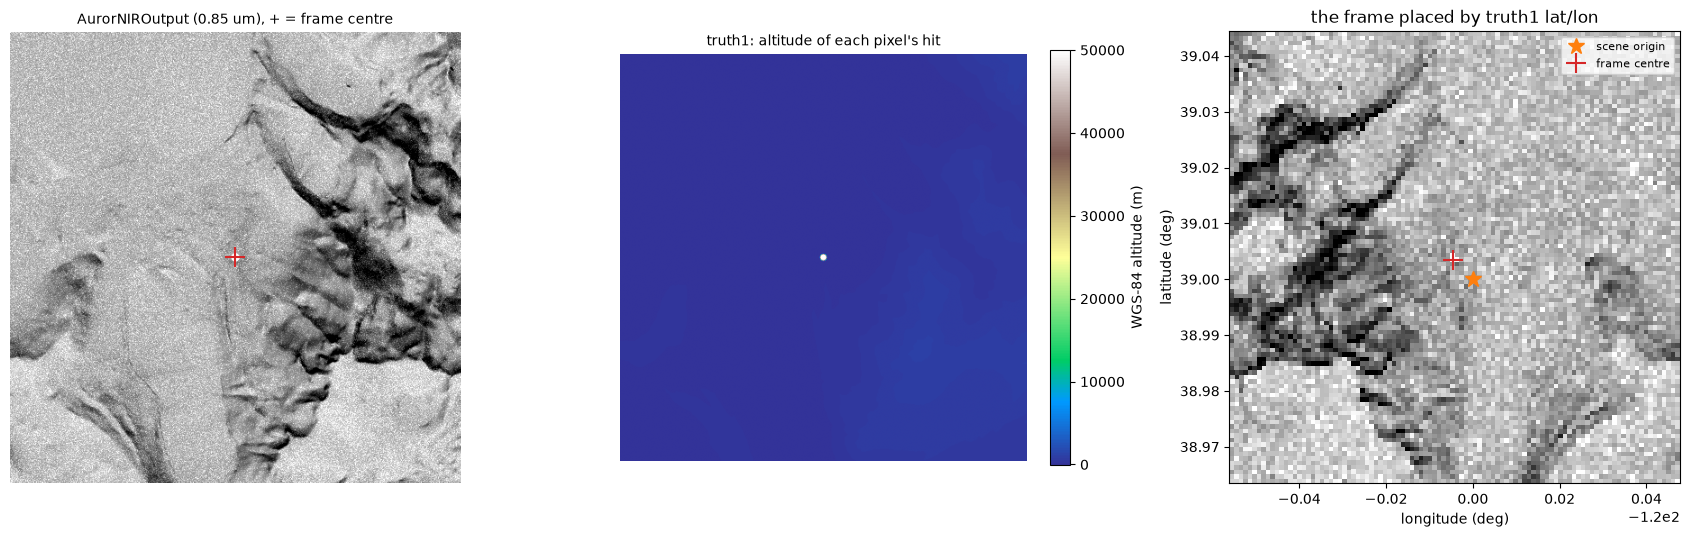

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import wgs84
from spectral import open_image
from protodirsig import orbit

img = open_image(str(OUT_DIR / "AurorNIROutput.img.hdr"))
rad = np.asarray(img.load(), dtype=float)[:, :, 0]
tr = open_image(str(OUT_DIR / "truth1.img.hdr"))
truth = {n: np.asarray(tr.read_band(i), dtype=float) for i, n in enumerate(tr.metadata["band names"])}
lat, lon, alt = (truth[k] for k in ("Geodetic Latitude [degrees +N]", "Geodetic Longitude [degrees +E]", "WGS84 Altitude [m]"))
ecef = np.dstack([truth[f"ECEF {a} Coordinate [m]"] for a in "XYZ"])

print(f"image  : {rad.shape}, {img.metadata['data units']}, band {img.metadata['band names']} at "
      f"{img.metadata['wavelength']} um; acquisition {img.metadata['acquisition time']}")
print(f"radiance range {rad.min():.3e} .. {rad.max():.3e}, median {np.median(rad):.3e}")
c = rad.shape[0] // 2
e, n, u = orbit.ecef_to_enu_matrix(LAT0, LON0) @ (ecef[c - 1:c + 1, c - 1:c + 1].reshape(-1, 3).mean(0)
                                                  - wgs84.latlon(LAT0, LON0, elevation_m=ALT0).itrs_xyz.m)
print(f"frame centre hits scene ENU ({e:.1f}, {n:.1f}, {u:.1f}) m; terrain in frame {np.nanmin(alt):.0f}..{np.nanmax(alt):.0f} m")
km_n = (lat.max() - lat.min()) * 111.0
km_e = (lon.max() - lon.min()) * 111.0 * np.cos(np.radians(LAT0))
print(f"footprint {km_e:.1f} km E-W x {km_n:.1f} km N-S (~{km_e * 1e3 / rad.shape[1]:.0f} m pixels); misses {np.isnan(alt).sum()}")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.4))
lo_, hi_ = np.percentile(rad, [1, 99])
ax[0].imshow(rad, cmap="gray", vmin=lo_, vmax=hi_)
ax[0].plot(c - 0.5, c - 0.5, "+", color="C3", ms=14, mew=1.5)
ax[0].set_title("AurorNIROutput (0.85 um), + = frame centre", fontsize=10); ax[0].axis("off")
m = ax[1].imshow(alt, cmap="terrain")
plt.colorbar(m, ax=ax[1], fraction=0.046, label="WGS-84 altitude (m)")
ax[1].set_title("truth1: altitude of each pixel's hit", fontsize=10); ax[1].axis("off")
ax[2].pcolormesh(lon[::5, ::5], lat[::5, ::5], rad[::5, ::5], cmap="gray", vmin=lo_, vmax=hi_, shading="auto")
ax[2].plot(LON0, LAT0, "*", color="C1", ms=12, label="scene origin")
ax[2].plot(lon[c, c], lat[c, c], "+", color="C3", ms=14, mew=1.5, label="frame centre")
ax[2].set(xlabel="longitude (deg)", ylabel="latitude (deg)", title="the frame placed by truth1 lat/lon")
ax[2].set_aspect(1 / np.cos(np.radians(LAT0))); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
assert np.hypot(e + 400, n - 400) < 18 and not np.isnan(alt).any()

**Reading the result.** The frame is the Tahoe terrain tile seen from straight above. All of it
is one grey material, so the contrast comes from relief: slope and shading. Fine pixel-to-pixel
grain is the renderer's Monte Carlo sampling noise. The truth image places every pixel on the
ground (no misses), with the frame centre directly under the sensor at scene `(-400, 400)`.
In the raw frame, row 0 is north but **column 0 is east**, so as rendered (pose yaw π, as
received) the image is mirror-imaged east to west compared with a map. The
third panel uses the truth latitude and longitude to place it correctly. (Checked from
`truth1`: longitude decreases from column 0 to column 499.)

**The disk is the bright spot at the frame centre.** The real vehicle inside it is still
invisible on its own; the cells below measure the disk.

## The visibility disk

The disk should cover about π·4² ≈ 50 pixels around the frame centre. The terrain truth can't
show it, because the geolocation truth reports the first surface each ray hits (the disk, 50 km
up, for these pixels; a fraction of each edge pixel). So this cell checks the image instead: the
mean signal inside 3 pixels of the centre (fully covered), against the frame median, and where
the pixels brighter than twice the frame median are. The brightest terrain is about 1.3 times
the median, so those can only be disk pixels.

disk core (32 px): 10.94 x the frame median (terrain ring: 0.98 x, std 0.042)
pixels above 2x the frame median: 60, all within 4.3 px of the centre (disk radius 4.0 px; edge pixels are partly covered)


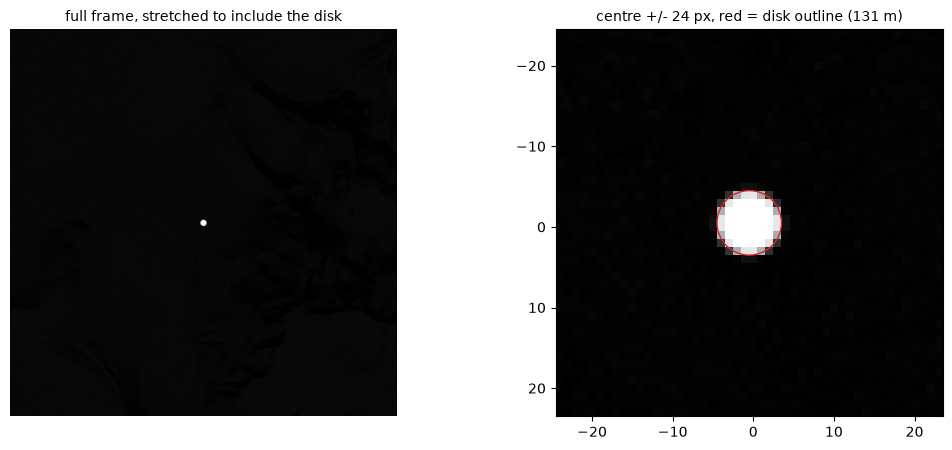

In [7]:
yy, xx = np.mgrid[:rad.shape[0], :rad.shape[1]]
r_px = np.hypot(yy - (c - 0.5), xx - (c - 0.5))           # distance from the frame centre, in pixels
core = r_px <= DISK_PIXELS / 2 - 1                          # fully inside the disk
ring = (r_px > DISK_PIXELS) & (r_px < 3 * DISK_PIXELS)      # terrain around it
bright = rad > 2 * np.median(rad)                           # terrain peaks at ~1.3x the median
print(f"disk core ({core.sum()} px): {rad[core].mean() / np.median(rad):.2f} x the frame median "
      f"(terrain ring: {rad[ring].mean() / np.median(rad):.2f} x, std {rad[ring].std() / np.median(rad):.3f})")
print(f"pixels above 2x the frame median: {bright.sum()}, all within {r_px[bright].max():.1f} px "
      f"of the centre (disk radius {DISK_PIXELS / 2} px; edge pixels are partly covered)")

h = 3 * DISK_PIXELS
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
ax[0].imshow(rad, cmap="gray", vmin=lo_, vmax=np.percentile(rad, 99.99))
ax[0].set_title("full frame, stretched to include the disk", fontsize=10); ax[0].axis("off")
ax[1].imshow(rad[c - h:c + h, c - h:c + h], cmap="gray", extent=(-h - .5, h - .5, h - .5, -h - .5))
ax[1].add_patch(plt.Circle((-0.5, -0.5), DISK_PIXELS / 2, fill=False, color="C3", lw=1))
ax[1].set_title(f"centre +/- {h} px, red = disk outline ({2 * DISK_RADIUS:.0f} m)", fontsize=10)
plt.tight_layout(); plt.show()
assert rad[core].mean() > 2 * np.median(rad) and r_px[bright].max() <= DISK_PIXELS / 2 + 1.5
